In [1]:
import os
from pathlib import Path # for eisy read folders

import tensorflow as tf ## libs for create model
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt  ### lib for visualization ..

print(f'Available GpU :  {tf.config.list_physical_devices('GPU')}' )

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Available GpU :  []


In [ ]:
# Data loading

# Base data link , In this folder that contains subfolders for each class
DATA_DIR = Path(r'PATH')  

batch_size = 32   ## for push images to model
img_size = (224, 224)  ### for resit image size
 

#### for set training data to model images from directory 
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)
##### for set validation data to model images from directory 

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',label_mode='int',validation_split=0.2,
    subset='validation',seed=123,image_size=img_size, 
    batch_size=batch_size
)

class_names = train_ds.class_names
print('Classes:', class_names,'\nnum of Classes ;',len(class_names))

###### Performance: cache adn prefetch

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3214 files belonging to 9 classes.
Using 2572 files for training.
Found 3214 files belonging to 9 classes.
Using 642 files for validation.
Classes: ['Abrasions', 'Bruises', 'Burns', 'Cut', 'Diabetic Wounds', 'Normal', 'Pressure Wounds', 'Surgical Wounds', 'Venous Wounds'] 
num of Classes ; 9


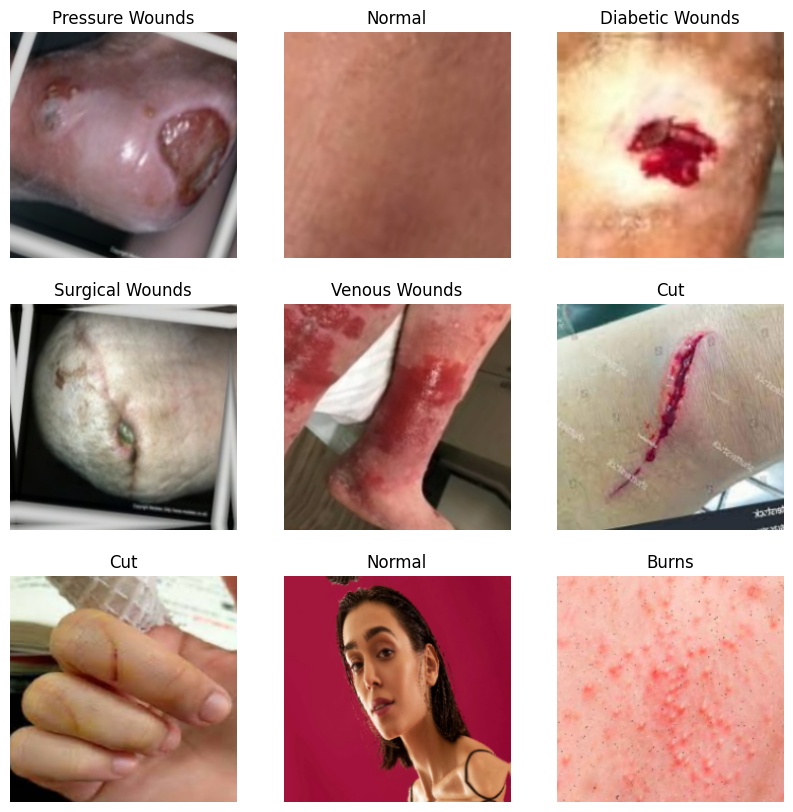

In [3]:
# Data augmentation for create more data images ... 

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'), ## horizontal from "-->"" to "<--""
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),     ## zooming on image to more evictve few on Wound .. 
])

### Visualiz a few augmented images 
import matplotlib.pyplot as plt
for images, labels in train_ds.take(1): 
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        img = images[i]
        aug_img = data_augmentation(tf.expand_dims(img, 0))
        plt.imshow((aug_img[0].numpy().astype("uint8")))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
    break

In [4]:
# Build the model (transfer learning with MobileNetV2)

base_model = keras.applications.MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)                ## data augmented 

x = keras.applications.mobilenet_v2.preprocess_input(x)   ### preprocess for data
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)    #### global avg pooling 
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(len(class_names), activation='softmax')(x)  ##### softmax  
model = keras.Model(inputs, outputs)     ###### creted model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
#Callbacks and training

callbacks = [
    ## for moitor loss function then save best case for model
    keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss'),

    ### even stop if loss begin incresing or loss== goal ...
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

#### num of terms
epochs = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.2678 - loss: 2.1716

81/81 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3872 - loss: 1.7820 - val_accuracy: 0.5872 - val_loss: 1.2078
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.5733 - loss: 1.1701

81/81 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5991 - loss: 1.1154 - val_accuracy: 0.6402 - val_loss: 1.0409
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6661 - loss: 0.9520

81/81 ━━━━━━━━━━━━━━━━━━━━ 70s 869ms/step - accuracy: 0.6684 - loss: 0.9433 - val_accuracy: 0.6994 - val_loss: 0.9578
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.6968 - loss: 0.9081

81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 883ms/step - accuracy: 0.7076 - loss: 0.8622 - val_accuracy: 0.7025 - val_loss: 0.8842
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.7074 - loss: 0.8292

...

81/81 ━━━━━━━━━━━━━━━━━━━━ 73s 901ms/step - accuracy: 0.7780 - loss: 0.6319 - val_accuracy: 0.7321 - val_loss: 0.7775
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.7768 - loss: 0.6085

81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 876ms/step - accuracy: 0.7795 - loss: 0.6309 - val_accuracy: 0.7477 - val_loss: 0.7542
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 894ms/step - accuracy: 0.7978 - loss: 0.6003 - val_accuracy: 0.7492 - val_loss: 0.7587
Epoch 12/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.7938 - loss: 0.5878

81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 883ms/step - accuracy: 0.7970 - loss: 0.5796 - val_accuracy: 0.7539 - val_loss: 0.7316
Epoch 13/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.8198 - loss: 0.5310

81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 877ms/step - accuracy: 0.8107 - loss: 0.5608 - val_accuracy: 0.7617 - val_loss: 0.7060
Epoch 14/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 70s 869ms/step - accuracy: 0.8161 - loss: 0.5364 - val_accuracy: 0.7570 - val_loss: 0.7168
Epoch 15/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.8362 - loss: 0.4799

81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 891ms/step - accuracy: 0.8231 - loss: 0.5178 - val_accuracy: 0.7726 - val_loss: 0.7057


In [ ]:
# Evaluate and save

loss, acc = model.evaluate(val_ds)
print(f'Val loss: {loss:.4f}, Val acc: {acc:.4f}')

# Save final model (TF SavedModel format)
model.save('final_model.h5')

# Quick prediction example
import numpy as np
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    print('Pred class:', np.argmax(preds, axis=1)[:15]) ##with encoding,, 
    print('actual class:', labels.numpy()[:15])
    break    
    ##==========================================================                  
    ### few deferant between predict and actual leable ..
    #==========================================================

#### for check if model be good predict and learning ..

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step - accuracy: 0.7726 - loss: 0.7057


Val loss: 0.7057, Val acc: 0.7726
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Pred class: [5 8 7 8 7 5 2 3 6 1 8 2 1 8 0]
actual class: [5 8 7 8 7 5 2 7 4 1 8 5 0 8 0]


In [ ]:
from sklearn.metrics import classification_report


y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=1)

report =classification_report(y_true, y_pred, target_names=class_names,output_dict=True)
print(report)


21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 684ms/step
{'Abrasions': {'precision': 0.8, 'recall': 0.5853658536585366, 'f1-score': 0.676056338028169, 'support': 41.0}, 'Bruises': {'precision': 0.6494845360824743, 'recall': 0.9545454545454546, 'f1-score': 0.7730061349693251, 'support': 66.0}, 'Burns': {'precision': 0.8478260869565217, 'recall': 0.582089552238806, 'f1-score': 0.6902654867256637, 'support': 67.0}, 'Cut': {'precision': 0.6842105263157895, 'recall': 0.7358490566037735, 'f1-score': 0.7090909090909091, 'support': 53.0}, 'Diabetic Wounds': {'precision': 0.8333333333333334, 'recall': 0.7777777777777778, 'f1-score': 0.8045977011494253, 'support': 90.0}, 'Normal': {'precision': 0.9322033898305084, 'recall': 0.9482758620689655, 'f1-score': 0.9401709401709402, 'support': 58.0}, 'Pressure Wounds': {'precision': 0.7529411764705882, 'recall': 0.7441860465116279, 'f1-score': 0.7485380116959064, 'support': 86.0}, 'Surgical Wounds': {'precision': 0.7446808510638298, 'recall': 0.7142857142857143, 'f1-s

<Axes: >

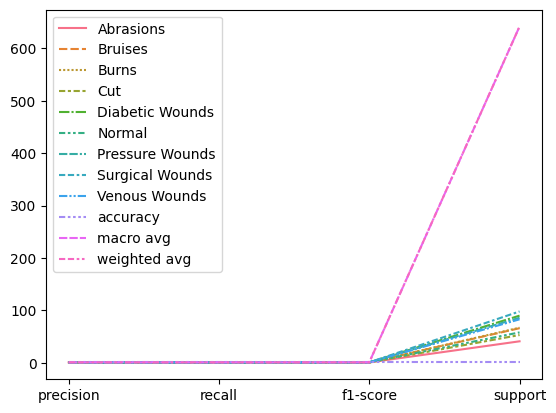

In [41]:
import pandas as pd
import seaborn as sns

report_df = pd.DataFrame(report)

sns.lineplot(report_df)

In [ ]:
import pathlib

p = pathlib.Path(r'path')

for i in os.listdir(p):
    a = os.path.join(p,i)
    print(f'{a} : ',len(os.listdir(a)))

Wound_dataset copy\Abrasions :  217
Wound_dataset copy\Bruises :  320
Wound_dataset copy\Burns :  342
Wound_dataset copy\Cut :  276
Wound_dataset copy\Diabetic Wounds :  416
Wound_dataset copy\Normal :  341
Wound_dataset copy\Pressure Wounds :  471
Wound_dataset copy\Surgical Wounds :  423
Wound_dataset copy\Venous Wounds :  430
